# Deep Learning

In questa lezione vedremo come utilizzare le librerie Keras (Tensorflow) e Pytorch per la costruzione di una rete neurale profonda.



# Keras (Tensorflow)

**Keras** è un’API ad alto livello per il deep learning che gira sopra **TensorFlow**.
TensorFlow è una piattaforma open source end-to-end sviluppata da Google per il machine learning e il deep learning. Consente di creare, addestrare e implementare modelli complessi su vari dispositivi (CPU, GPU, TPU).

Utilizzato per l'elaborazione del linguaggio naturale (NLP), la visione artificiale e la ricerca, è uno standard del settore ed è basata su uso dei tensori.

Un tensore è un oggetto matematico e geometrico, rappresentabile come un array multidimensionale di numeri, che generalizza scalari (rango 0), vettori (rango 1) e matrici (rango 2) a un numero qualsiasi di dimensioni.


Keras è utilizzata per:

* Definire modelli neurali
* Allenarli
* Valutarli
* Fare predizioni

È progettata per essere:

* semplice
* leggibile
* modulare

---

# Le 5 Parti Fondamentali di un Modello di Classificazione

Quando lavori in Keras, il flusso è sempre questo:

```
1. Import librerie
2. Preparazione dati
3. Definizione modello
4. Compilazione
5. Training (fit)
6. Valutazione / Predizione
```

Vediamole una per una.

---

# Import delle librerie

```python
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
```

---

#  Preparazione dei dati

Un modello di classificazione ha:

* **X** → input (feature)
* **y** → etichette (classi)

Esempio:

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
```

Spesso serve anche:

* Normalizzazione
* One-hot encoding (se multiclasse)

---

# Definizione del modello

In Keras puoi usare:

* `Sequential()` → modello lineare semplice
* API funzionale → modelli complessi

Per iniziare usiamo Sequential.

```python
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(num_features,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
```

## Cosa significa?

* `Dense` → layer completamente connesso
* `relu` → attivazione non lineare
* `softmax` → output per classificazione multiclasse

Se è classificazione binaria:

```python
layers.Dense(1, activation='sigmoid')
```

---

# Compilazione del modello

Qui definiamo:

* funzione di perdita
* ottimizzatore
* metriche

```python
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
```

### Perdita corretta:

| Problema                     | Loss                              |
| ---------------------------- | --------------------------------- |
| Binaria                      | `binary_crossentropy`             |
| Multiclasse                  | `categorical_crossentropy`        |
| Multiclasse con label intere | `sparse_categorical_crossentropy` |

---

# Training

```python
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)
```

Cosa succede qui?

* Forward pass
* Calcolo loss
* Backpropagation
* Aggiornamento pesi
* Ripete per ogni epoca

`history` salva le metriche.

---

# Valutazione

```python
test_loss, test_acc = model.evaluate(X_test, y_test)
```

---

# Predizione

```python
predictions = model.predict(X_test)
```

Se è multiclasse:

```python
import numpy as np
predicted_classes = np.argmax(predictions, axis=1)
```

---

#  Plot delle metriche

```python
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'validation'])
plt.title('Accuracy')
plt.show()
```

---

# Cosa Succede Internamente?

Quando chiami `fit()`:

1. Fa il forward pass
2. Calcola la loss
3. Usa la regola della catena
4. Calcola i gradienti
5. L’ottimizzatore aggiorna i pesi

Keras automatizza tutta la matematica.

---

#  Struttura Minima di un Modello di Classificazione

```python
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X.shape[1],)),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=10)

model.evaluate(X_test, y_test)
```





TensorFlow version: 2.19.0
Keras è integrato in TensorFlow a partire dalla 2.0+

Dimensioni dei dati:
Train images: (60000, 28, 28)
Train labels: (60000,)
Test  images: (10000, 28, 28)
Test  labels: (10000,)


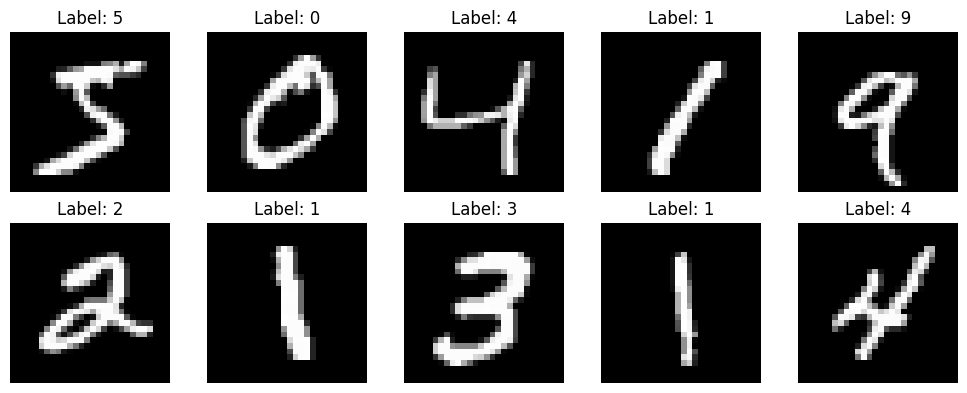


Nuove forme dopo preprocessing:
x_train: (60000, 28, 28)
x_test : (10000, 28, 28)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Inizio addestramento...

Epoch 1/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8239 - loss: 0.6300 - val_accuracy: 0.9595 - val_loss: 0.1470
Epoch 2/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9541 - loss: 0.1580 - val_accuracy: 0.9662 - val_loss: 0.1119
Epoch 3/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9696 - loss: 0.1042 - val_accuracy: 0.9700 - val_loss: 0.1024
Epoch 4/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9776 - loss: 0.0759 - val_accuracy: 0.9753 - val_loss: 0.0843
Epoch 5/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9825 - loss: 0.0596 - val_accuracy: 0.9790 - val_loss: 0.0736
Epoch 6/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9876 - loss: 0.0433 - val_accuracy: 0.9787 - val_loss: 0.0775
Epoch 7/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9889 - loss: 0.0379 - val_accuracy: 0.9745 - val_loss: 0.0890
Epoch 8/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9912 - loss:

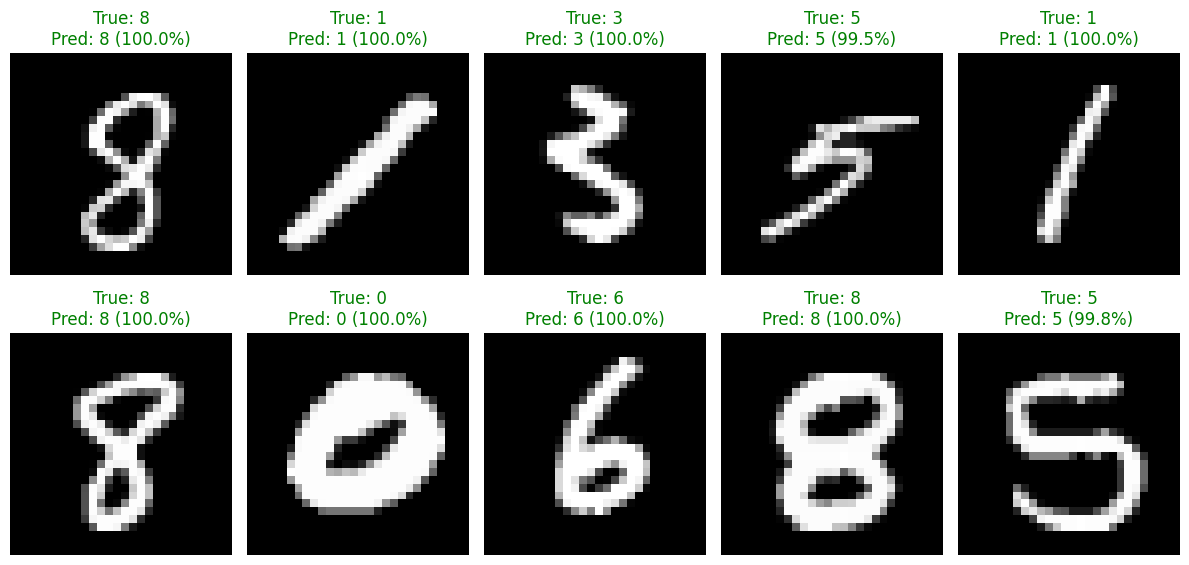

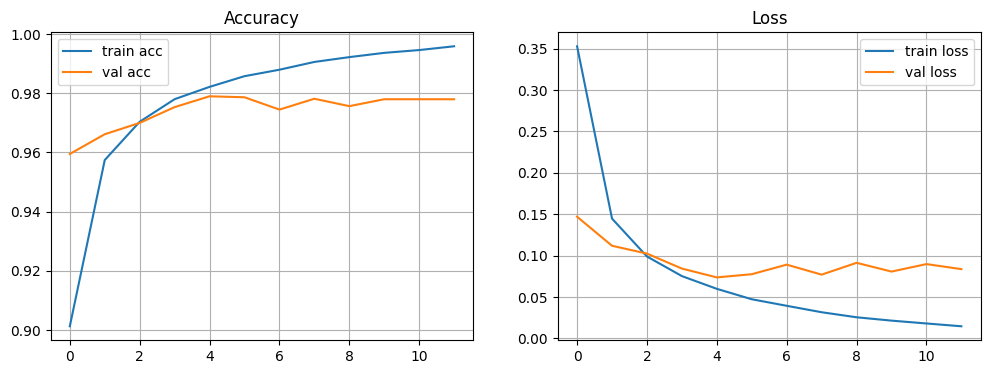

In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   ALLENA RETI NEURALI CON KERAS (TENSORFLOW)                 ║
# ║   Lezione base - Classificazione MNIST                       ║
# ╚══════════════════════════════════════════════════════════════╝

# Importiamo le librerie che ci servono
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("Keras è integrato in TensorFlow a partire dalla 2.0+")

# ────────────────────────────────────────────────────────────────
# 1. Carichiamo il dataset
# ────────────────────────────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("\nDimensioni dei dati:")
print("Train images:", x_train.shape)   # 60.000 immagini 28×28
print("Train labels:", y_train.shape)   # 60.000 etichette
print("Test  images:", x_test.shape)    # 10.000 immagini
print("Test  labels:", y_test.shape)

# ────────────────────────────────────────────────────────────────
# 2. Esploriamo visivamente qualche esempio
# ────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────────────────────
# 3. Preprocessiamo i dati
# IMPORTANTE: a differenza di altri approcci nel deeplearning
# il preprocessing è fondamentale!
# ────────────────────────────────────────────────────────────────

# Normalizziamo i pixel da 0-255 → 0-1
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# Aggiungiamo la dimensione dei canali → shape diventa (N, 28, 28, 1)
# (necessario per la maggior parte delle reti convoluzionali, ma anche per le dense va bene)


#Cosa succede esattamente con axis=-1
#axis=-1 significa: aggiungi la nuova dimensione all'ultima posizione
#Prima:
#(60000, 28, 28)
#Dopo np.expand_dims(..., axis=-1):
#(60000, 28, 28, **1**)
#È la convenzione standard in TensorFlow/Keras (canale per ultimo = "channels_last").

#x_train = np.expand_dims(x_train, axis=-1)
#x_test  = np.expand_dims(x_test,  axis=-1)



print("\nNuove forme dopo preprocessing:")
print("x_train:", x_train.shape)
print("x_test :", x_test.shape)

# ────────────────────────────────────────────────────────────────
# 4. Costruiamo la rete neurale (versione più semplice - solo Dense)
# ────────────────────────────────────────────────────────────────

model = keras.Sequential([
    # Trasformiamo l'immagine 28×28 in un vettore di 784 elementi
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),

    # Livelli densi (fully connected)
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),

    # Output: 10 classi → usiamo softmax
    layers.Dense(10, activation='softmax')
])

# Possiamo anche scriverla così (stile più esplicito):
"""
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28, 1)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(10,  activation='softmax')
])
"""

model.summary()

# ────────────────────────────────────────────────────────────────
# 5. Compiliamo il modello (scelta di loss, ottimizzatore, metriche)
# ────────────────────────────────────────────────────────────────

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',    # usiamo sparse perché le label sono interi 0-9
    metrics=['accuracy']
)

# ────────────────────────────────────────────────────────────────
# 6. Addestriamo il modello
# ────────────────────────────────────────────────────────────────

print("\nInizio addestramento...\n")

history = model.fit(
    x_train, y_train,
    epochs=12,               # prova anche 12–15 se vuoi miglior accuracy
    batch_size=128,
    validation_split=0.1,   # usa il 10% dei dati di train come validazione
    verbose=1
)

# ────────────────────────────────────────────────────────────────
# 7. Valutiamo sul test set
# ────────────────────────────────────────────────────────────────

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"\nRisultato sul test set:")
print(f"Accuracy: {test_acc:.4f}")
print(f"Loss:     {test_loss:.4f}")

# ────────────────────────────────────────────────────────────────
# 8. Facciamo qualche previsione e la visualizziamo
# ────────────────────────────────────────────────────────────────

# Prendiamo 10 immagini a caso dal test set
indices = np.random.choice(len(x_test), size=10, replace=False)

plt.figure(figsize=(12, 6))

for i, idx in enumerate(indices):
    img = x_test[idx]
    true_label = y_test[idx]

    pred = model.predict(img[np.newaxis, ...], verbose=0)[0]
    pred_label = np.argmax(pred)
    confidence = pred[pred_label] * 100

    plt.subplot(2, 5, i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────────────────────
# Bonus: Grafico andamento accuracy e loss
# ────────────────────────────────────────────────────────────────

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss')
plt.legend()
plt.grid(True)

plt.show()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)


Addestramento modello più grande con Dropout...

Epoch 1/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.8333 - loss: 0.5431 - val_accuracy: 0.9727 - val_loss: 0.0975
Epoch 2/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9611 - loss: 0.1303 - val_accuracy: 0.9777 - val_loss: 0.0791
Epoch 3/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9713 - loss: 0.0929 - val_accuracy: 0.9768 - val_loss: 0.0823
Epoch 4/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9780 - loss: 0.0717 - val_accuracy: 0.9818 - val_loss: 0.0597
Epoch 5/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9819 - loss: 0.0558 - val_accuracy: 0.9795 - val_loss: 0.0690
Epoch 6/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9844 - loss: 0.0498 - val_accuracy: 0.9785 - val_loss: 0.0750
Epoch 7/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9844 - loss: 0.0466 - val_accuracy: 0.9827 - val_loss: 0.0668
Epoch 8/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15m

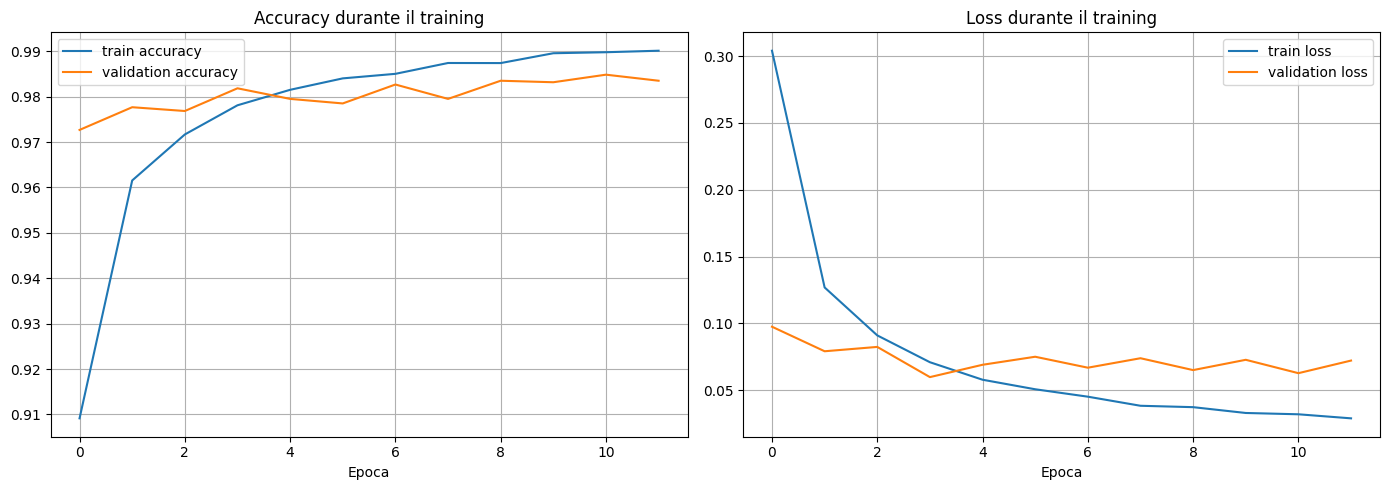

In [3]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   RETE CON PIÙ NEURONI + DROPOUT                             ║
# ║   Variante più potente (ma attenzione all'overfitting)       ║
# ╚══════════════════════════════════════════════════════════════╝

# ---------------------------------------------------------------
# Costruiamo una rete più capace con Dropout anti-overfitting
# ---------------------------------------------------------------

model = keras.Sequential([
    # Input: immagini 28×28 in scala di grigi (1 canale)
    layers.Input(shape=(28, 28, 1)),

    # Appiattiamo l'immagine in un vettore
    layers.Flatten(),

    # Primo layer denso – molto più neuroni
    layers.Dense(512, activation='relu', name='dense_1'),
    # Dropout: spegne casualmente il 30% dei neuroni ad ogni passo
    # aiuta moltissimo a prevenire l'overfitting su dataset piccoli/medi
    layers.Dropout(0.3),

    # Secondo layer denso – ancora capiente
    layers.Dense(256, activation='relu', name='dense_2'),
    # Altro dropout, un po' più leggero
    layers.Dropout(0.2),

    # Output: 10 classi (cifre 0-9)
    layers.Dense(10, activation='softmax', name='output')
])

# Versione compatta alternativa (stesso identico modello)
"""
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28, 1)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10,  activation='softmax')
])
"""

# Mostra la struttura del modello (molto più parametri ora!)
model.summary()

# ---------------------------------------------------------------
# Compilazione – invariata
# ---------------------------------------------------------------

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ---------------------------------------------------------------
# Addestramento – possiamo permetterci qualche epoca in più
# Attenzione alla validation loss
# ---------------------------------------------------------------

print("\nAddestramento modello più grande con Dropout...\n")

history = model.fit(
    x_train, y_train,
    epochs=12,               # ← aumentato un po' rispetto a prima
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# ---------------------------------------------------------------
# Valutazione sul test set
# ---------------------------------------------------------------

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nRisultato sul test set (modello grande + dropout):")
print(f"→ Accuracy: {test_acc:.4f}")
print(f"→ Loss:     {test_loss:.4f}")

# ---------------------------------------------------------------
# Grafico per capire se c'è overfitting
# ---------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.title('Accuracy durante il training')
plt.xlabel('Epoca')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.title('Loss durante il training')
plt.xlabel('Epoca')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Osservazioni utili
# Se validation loss sale mentre train loss scende → overfitting
# Il Dropout aiuta proprio a ridurre questo divario")
#  TO DO: fare tentatitivi variando valori di Dropout (0.2–0.5) e con il numero di epoche

# Approfondimento sul flusso standard in Keras

Come visto in precedentza ogni modello segue più o meno questo schema:

```
1. Preparazione dati
2. Definizione modello
3. Compilazione
4. Training (fit)
5. Valutazione
6. Predizione
7. Salvataggio
```


Vediamo di approfondire i singoli step.

---

# Preparazione Dati

Esempio generico:

```python
import numpy as np
from sklearn.model_selection import train_test_split

X = np.random.rand(1000, 20)
y = np.random.randint(0, 2, 1000)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
```

 Importante:

* Input → float32
* Classificazione multiclasse → eventualmente one-hot encoding

---

# Creazione del Modello

## Metodo 1: Sequential (più semplice)

```python
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(20,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
```

### Quando usarlo?

* Architettura lineare (un layer dopo l’altro)

---

## Metodo 2: Functional API (più flessibile)

```python
inputs = keras.Input(shape=(20,))
x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)
```

### Quando usarlo?

* Più input
* Più output
* Architetture complesse
* Skip connections (tipo ResNet)

---

# Differenza fra Sequential e Functional API

La differenza tra **`Sequential`** e **Functional API** in **Keras** riguarda **la flessibilità dell’architettura del modello**.


#  Modello `Sequential`:  Cos’è?

È il modo **più semplice** per costruire una rete neurale:
i layer vengono impilati uno dopo l’altro in modo lineare.

Struttura:

```
Input → Layer1 → Layer2 → Layer3 → Output
```

---

##  Esempio

```python
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(20,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
```

---

## Quando usarlo?

* Modelli semplici
* Un solo input
* Un solo output
* Nessuna connessione complessa

---

##  Limiti

Non puoi fare:

* Più input
* Più output
* Layer che si uniscono (merge)
* Skip connections (tipo ResNet)
* Architetture non lineari

---

# Cenni di approfondimento su Functional API

È un modo più flessibile per costruire modelli come **grafi computazionali**.

Struttura:

```
        ↘ Layer2 ↘
Input → Layer1 → Merge → Output
        ↗ Layer3 ↗
```

Puoi creare:

* Branch paralleli
* Connessioni multiple
* Modelli complessi

---

##  Esempio equivalente al Sequential

```python
inputs = keras.Input(shape=(20,))
x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs)
```

Questo è equivalente al Sequential sopra.

---

# Esempio che Sequential NON può fare: modello con due input

```python
input1 = keras.Input(shape=(10,))
input2 = keras.Input(shape=(5,))

x1 = layers.Dense(32, activation='relu')(input1)
x2 = layers.Dense(32, activation='relu')(input2)

merged = layers.concatenate([x1, x2])
output = layers.Dense(1, activation='sigmoid')(merged)

model = keras.Model(inputs=[input1, input2], outputs=output)
```

Con `Sequential` questo non è possibile.

---

# Differenza concettuale

| Sequential                | Functional API             |
| ------------------------- | -------------------------- |
| Lineare                   | Grafo                      |
| Più semplice              | Più flessibile             |
| Adatto a modelli standard | Adatto a modelli complessi |
| 1 input / 1 output        | Multi-input / multi-output |

---

# Differenza Filosofica

* `Sequential` = "stack di layer"
* `Functional API` = "grafo di operazioni"

---

# Quando usare cosa?

### Usa Sequential se:

* Stai imparando
* Il modello è semplice
* È una rete classica feed-forward o CNN lineare

### Usa Functional API se:

* Vuoi costruire qualcosa di avanzato
* Hai architetture tipo ResNet, U-Net
* Hai modelli multimodali (immagine + testo)
* Vuoi riutilizzare parti del modello

---

#  Esempio: Skip Connection (tipo ResNet)

```python
inputs = keras.Input(shape=(64,))
x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dense(64)(x)

# skip connection
x = layers.add([x, inputs])
x = layers.Activation('relu')(x)

outputs = layers.Dense(10, activation='softmax')(x)

model = keras.Model(inputs, outputs)
```

Questo è impossibile con Sequential.

---

#  In sintesi

Sequential è un **caso particolare** della Functional API.

Se il tuo modello è lineare:

```
Input → A → B → C → Output
```

puoi usare Sequential.

Se diventa:

```
        ↘ B ↘
Input → A → Merge → Output
        ↗ C ↗
```

serve Functional API.


----
# Tipi di Layer che puoi usare

## Dense (fully connected)

```python
layers.Dense(units, activation='relu')
```

---

## Convolution (per immagini)

```python
layers.Conv2D(32, (3,3), activation='relu')
layers.MaxPooling2D((2,2))
layers.Flatten()
```

---

## Dropout (regolarizzazione)

```python
layers.Dropout(0.5)
```

Riduce overfitting spegnendo neuroni casualmente.

---

## Batch Normalization

```python
layers.BatchNormalization()
```

Stabilizza il training.

---

## LSTM / GRU (serie temporali)

```python
layers.LSTM(64)
layers.GRU(32)
```

---

# Compilazione del Modello

Qui definisci:

* Ottimizzatore
* Funzione di perdita
* Metriche

```python
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
```

---

## Scelta della Loss

| Problema                     | Loss                              |
| ---------------------------- | --------------------------------- |
| Binaria                      | `binary_crossentropy`             |
| Multiclasse                  | `categorical_crossentropy`        |
| Multiclasse con label intere | `sparse_categorical_crossentropy` |
| Regressione                  | `mse`                             |

---

# Training

```python
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)
```

Cosa fa `fit()` internamente?

1. Forward pass
2. Calcolo loss
3. Backpropagation
4. Aggiornamento pesi
5. Ripete per ogni epoca

---

#  Monitorare le metriche

```python
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'validation'])
plt.show()
```

---

# Valutazione

```python
test_loss, test_acc = model.evaluate(X_test, y_test)
```

---

# Predizione

```python
predictions = model.predict(X_test)
```

Per classificazione:

```python
import numpy as np
predicted_classes = np.argmax(predictions, axis=1)
```

---

# Callback (Funzionalità Avanzate)

Le callback permettono di controllare il training.

##  Early Stopping

```python
callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3
)
```

## Model Checkpoint

```python
keras.callbacks.ModelCheckpoint("best_model.keras")
```

Uso:

```python
model.fit(..., callbacks=[callback])
```

---

# Salvare e Caricare Modello

Salvare:

```python
model.save("model.keras")
```

Caricare:

```python
model = keras.models.load_model("model.keras")
```

---

# Struttura Completa di un Modello Reale

```python
model = keras.Sequential([
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(X_train, y_train, epochs=20, validation_split=0.2)
```

---

#  Concettualmente cosa succede?

Ogni modello Keras è composto da:

* **Struttura (Layer)**
* **Funzione di costo**
* **Algoritmo di ottimizzazione**
* **Dati**
* **Ciclo di training**

Keras automatizza completamente:

* Derivate
* Backpropagation
* Aggiornamento pesi

---

# Riepilogo

Per creare un modello in Keras devi sempre definire:

1. Architettura (layer)
2. Loss
3. Optimizer
4. Metriche
5. Training

---





#  Come funziona PyTorch per la classificazione

PyTorch è probabilmente la libreria emergente sul deep learning. E' più “manuale” rispetto a Keras. Offre maggiore controllo  ma richiede di scrivere esplicitamente il ciclo di training.
Nel campo della ricerca è attualmente lo standard più utilizzato.



Il flusso in PyTorch è:

```
1. Import librerie
2. Preparazione dati (Tensor + DataLoader)
3. Definizione del modello
4. Definizione loss e optimizer
5. Training loop
6. Valutazione / Predizione
```

---

# Import delle librerie

```python
import torch
import torch.nn as nn
import torch.optim as optim
```

---

# Preparazione dei dati

PyTorch lavora con **tensor**, non array NumPy.

```python
from sklearn.model_selection import train_test_split
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Conversione in tensor
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)
```

Per training efficiente si usa `DataLoader`:

```python
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
```

---

# Definizione del modello

In PyTorch si crea una classe che eredita da `nn.Module`.

```python
class Classifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(Classifier, self).__init__()
        
        self.layer1 = nn.Linear(input_dim, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, num_classes)
        
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.output(x)
        return x
```

Creiamo il modello:

```python
model = Classifier(input_dim=X_train.shape[1], num_classes=3)
```

 Nota: l’output NON ha softmax se usiamo `CrossEntropyLoss` (lo applica internamente).

---

# Loss e Optimizer

```python
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
```

Scelta loss:

| Problema    | Loss                  |
| ----------- | --------------------- |
| Binaria     | `BCEWithLogitsLoss()` |
| Multiclasse | `CrossEntropyLoss()`  |

---

#  Training Loop (la parte che in Keras è automatica)

```python
epochs = 20

for epoch in range(epochs):
    
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        
        optimizer.zero_grad()        # reset gradienti
        
        outputs = model(inputs)      # forward pass
        
        loss = criterion(outputs, labels)  # loss
        
        loss.backward()              # backpropagation
        
        optimizer.step()             # aggiornamento pesi
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")
```

---

#  Cosa succede dentro il loop?

Ogni batch:

1. `forward()` → calcola output
2. `loss()` → errore
3. `backward()` → calcola gradienti (regola della catena)
4. `step()` → aggiorna pesi

PyTorch usa **autograd** per calcolare automaticamente le derivate.

---

#  Valutazione

```python
model.eval()

correct = 0
total = 0

with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)
    
    total += y_test.size(0)
    correct += (predicted == y_test).sum().item()

accuracy = correct / total
print("Accuracy:", accuracy)
```

---

#  Predizione

```python
model.eval()

with torch.no_grad():
    outputs = model(X_test)
    _, predicted_classes = torch.max(outputs, 1)
```

---

# Plot delle metriche

PyTorch non salva automaticamente la history come Keras, quindi la creiamo noi:

```python
import matplotlib.pyplot as plt

loss_history = []

for epoch in range(epochs):
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    loss_history.append(running_loss)

plt.plot(loss_history)
plt.title("Training Loss")
plt.show()
```

---

# Differenza concettuale con Keras

| Keras                     | PyTorch                    |
| ------------------------- | -------------------------- |
| `model.fit()` automatico  | Loop scritto a mano        |
| Molto alto livello        | Più controllo              |
| Più semplice per iniziare | Più flessibile per ricerca |

Keras gira sopra **TensorFlow**, mentre PyTorch è un framework separato.

---

# Struttura Minima PyTorch per Classificazione

```python
model = Classifier(X_train.shape[1], 3)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

for epoch in range(10):
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
```

---

#  Riassunto

Per classificare in PyTorch ti servono:

1. Tensor
2. Modello (`nn.Module`)
3. Loss
4. Optimizer
5. Training loop
6. Valutazione manuale

---


Facciamo la **versione CNN in PyTorch per classificazione di immagini** (es. MNIST/CIFAR-like).

Useremo **PyTorch**.

---

#  Mini-Lezione: CNN in PyTorch per Classificazione

---

#  Struttura di una CNN

Una CNN tipica ha:

```
Conv → ReLU → Pool
Conv → ReLU → Pool
Flatten
Fully Connected
Output
```

Le convoluzioni estraggono feature spaziali (bordi, pattern, forme).

---

# 2️⃣ Import

```python
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
```

---

#  Modello CNN

Supponiamo immagini 28x28 in scala di grigio (1 canale, tipo MNIST).

```python
class CNNClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super(CNNClassifier, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        
        # Fully connected layers
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # 28x28 → 14x14
        x = self.pool(self.relu(self.conv2(x)))   # 14x14 → 7x7
        
        x = x.view(x.size(0), -1)                 # Flatten
        
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x
```

---

# Perché 32 * 7 * 7?

Calcolo dimensioni:

```
28x28
↓ Conv (padding=1) → 28x28
↓ MaxPool(2) → 14x14
↓ Conv → 14x14
↓ MaxPool(2) → 7x7
```

Output finale:

```
32 feature map da 7x7
```

---

# Inizializzazione modello

```python
model = CNNClassifier(num_classes=10)
```

---

# Loss e Optimizer

Per classificazione multiclasse:

```python
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
```

 Niente softmax nel modello → `CrossEntropyLoss` lo applica internamente.

---

# Training Loop

```python
epochs = 10
loss_history = []

for epoch in range(epochs):
    
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    loss_history.append(running_loss)
    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")
```

---

#  Valutazione

```python
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Accuracy:", correct / total)
```

---

# Plot della Loss

```python
plt.plot(loss_history)
plt.title("Training Loss")
plt.show()
```

---

# Cosa Succede Internamente

Durante il forward:

1. `Conv2d` applica filtri convoluzionali
2. `ReLU` introduce non linearità
3. `MaxPool` riduce dimensione spaziale
4. `Linear` combina feature per classificazione

Durante `loss.backward()`:

* Autograd applica la regola della catena
* Calcola gradienti per:

  * filtri convoluzionali
  * pesi fully connected

---

# Struttura Minima CNN

```python
model = CNNClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

for epoch in range(5):
    outputs = model(images)
    loss = criterion(outputs, labels)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
```

---


Per una CNN in PyTorch servono:

1. `nn.Conv2d`
2. `nn.MaxPool2d`
3. `nn.Linear`
4. `CrossEntropyLoss`
5. Training loop manuale

---



Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 23.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 615kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.38MB/s]


Epoch 1/5, Loss: 175.6268
Epoch 2/5, Loss: 48.7426
Epoch 3/5, Loss: 35.0878
Epoch 4/5, Loss: 27.0209
Epoch 5/5, Loss: 20.2987

Test Accuracy: 0.9893


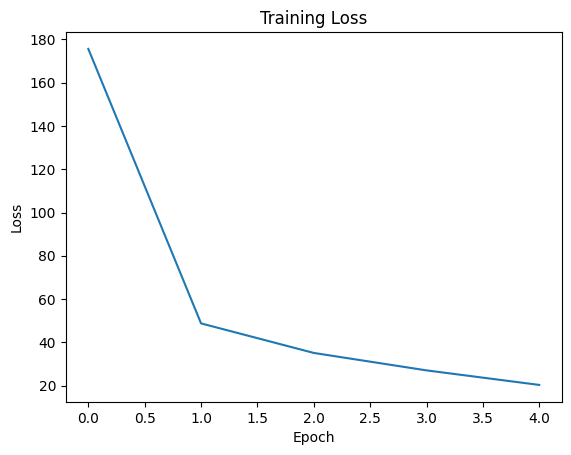

In [4]:
# ===============================
# CNN COMPLETA PER MNIST - PyTorch
# ===============================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# -------------------------------
#  Device (CPU / GPU)
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------
#  Dataset MNIST
# -------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# -------------------------------
#  Modello CNN
# -------------------------------
class CNNClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super(CNNClassifier, self).__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 28x28 → 14x14
        x = self.pool(self.relu(self.conv2(x)))  # 14x14 → 7x7

        x = x.view(x.size(0), -1)                # Flatten

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

model = CNNClassifier().to(device)

# -------------------------------
#  Loss e Optimizer
# -------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# -------------------------------
#  Training
# -------------------------------
epochs = 5
loss_history = []

for epoch in range(epochs):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    loss_history.append(running_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss:.4f}")

# -------------------------------
# Valutazione
# -------------------------------
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f"\nTest Accuracy: {accuracy:.4f}")

# -------------------------------
# Plot Loss
# -------------------------------
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


#  Architetture delle Reti Neurali: Da Feedforward ai Transformer

In questa sezione affronteremo il tema di come creare una rete neurale. La cosa non è per niente semplice. Nel tempo la ricerca ha portato a sviluppare delle architetture che si è visto funzionano in determinati contesti/problemi/tipologie di dati.


Ricordiamo, infatti, che le reti neurali sono strumenti **universali** di approssimazione, ma la loro efficacia dipende dall'**architettura** scelta in base al tipo di dati:

| Tipo di Dato | Architettura Ottimale | Perché? |
|---|---|---|
| Dati tabulari | **Feedforward (MLP)** | Nessuna struttura spaziale/temporale |
| Immagini | **CNN** | Sfrutta località e invarianza traslazionale |
| Sequenze (testo, audio) | **RNN, LSTM, GRU** | Cattura dipendenze temporali |
| Sequenze lunghe | **Transformer** | Attenzione globale, parallelizzabile |
| Grafi | **GNN** | Propaga informazione su strutture non euclidee |

> **Principio chiave:** L'architettura giusta introduce **inductive bias** (assunzioni strutturali) che accelerano l'apprendimento e migliorano la generalizzazione.

---

##  Feedforward Neural Networks (MLP)


La rete **Multilayer Perceptron (MLP)** è l'architettura più semplice: strati completamente connessi (fully connected layers).

$$\mathbf{h}^{(l)} = \sigma\left(\mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}\right)$$

dove:
- $\mathbf{h}^{(l)} \in \mathbb{R}^{n_l}$ è l'attivazione dello strato $l$
- $\mathbf{W}^{(l)} \in \mathbb{R}^{n_l \times n_{l-1}}$ è la matrice dei pesi
- $\sigma(\cdot)$ è la funzione di attivazione (ReLU, sigmoid, tanh)

**Struttura completa:**

```
Input (x) → [FC + ReLU] → [FC + ReLU] → ... → [FC] → Output (ŷ)
```

###  Caratteristiche

**Vantaggi:**
- Semplice da implementare
- Teorema di approssimazione universale (con un solo hidden layer infinito)
- Funziona bene su dati tabulari

 **Svantaggi:**
- **Numero di parametri esplosivo**: per immagini 256×256 RGB → $256 \times 256 \times 3 = 196{,}608$ parametri solo nel primo layer
- **Non sfrutta struttura locale**: ogni pixel è trattato indipendentemente
- **Non invariante a traslazioni**: spostare un oggetto nell'immagine crea un input completamente diverso

###  Esempio in PyTorch

```python
import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes):
        super(MLP, self).__init__()
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.5))  # Regolarizzazione
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        return self.network(x)

# Esempio: classificazione MNIST (28×28 grayscale)
model = MLP(input_size=784, hidden_sizes=[512, 256], num_classes=10)
print(model)
```

---

## Convolutional Neural Networks (CNN)

Le CNN nascono per risolvere i problemi individuati in precedenza sui MLP applicati alle immagini.

Un'immagine 224×224 RGB ha $224 \times 224 \times 3 = 150{,}528$ pixel. Con un MLP:

- Primo hidden layer da 1000 neuroni: $150{,}528 \times 1000 = 150$ **milioni** di parametri
- Overfitting garantito
- Ignora la struttura 2D dell'immagine



**Vantaggio delle CNN:**

Le immagini hanno **località** (pixel vicini sono correlati) e **invarianza traslazionale** (un gatto è sempre un gatto, ovunque appaia nell'immagine).

### Operazione di Convoluzione

La **convoluzione 2D** applica un filtro (kernel) $\mathbf{K}$ sull'input $\mathbf{X}$:

$$(\mathbf{X} * \mathbf{K})[i,j] = \sum_{m}\sum_{n} \mathbf{X}[i+m, j+n] \cdot \mathbf{K}[m,n]$$

**Esempio:** filtro 3×3 per rilevare bordi verticali:

$$\mathbf{K}_{\text{vertical}} = \begin{pmatrix} -1 & 0 & 1 \\ -1 & 0 & 1 \\ -1 & 0 & 1 \end{pmatrix}$$

###  Vantaggi della Convoluzione

1. **Condivisione dei parametri (weight sharing):** lo stesso filtro viene applicato ovunque → drastica riduzione parametri
2. **Località:** ogni neurone guarda solo una regione locale (campo recettivo)
3. **Invarianza traslazionale:** un pattern rilevato in (10,10) viene rilevato anche in (50,50)


**Confronto parametri:**

| Architettura | Parametri per layer (224×224→1000) |
|---|---|
| MLP (fully connected) | $150{,}528 \times 1000 = 150M$ |
| CNN (64 filtri 3×3) | $3 \times 3 \times 3 \times 64 = 1{,}728$ |

###  Building Blocks delle CNN

**Conv Layer:**
$$\mathbf{H}^{(l)} = \sigma\left(\mathbf{W}^{(l)} * \mathbf{H}^{(l-1)} + \mathbf{b}^{(l)}\right)$$

**Pooling Layer:** riduce la dimensionalità spaziale

$$\text{MaxPool}(\mathbf{X})[i,j] = \max_{m,n \in \text{window}} \mathbf{X}[i+m, j+n]$$

**Architettura tipica:**

```
Input (3×224×224)
  ↓ Conv(64, 3×3) + ReLU
  ↓ MaxPool(2×2)        → (64×112×112)
  ↓ Conv(128, 3×3) + ReLU
  ↓ MaxPool(2×2)        → (128×56×56)
  ↓ Conv(256, 3×3) + ReLU
  ↓ GlobalAvgPool       → (256×1×1)
  ↓ Flatten + FC        → (num_classes)
Output (logits)
```

### Cenni ad  architetture CNN Famose

Nel tempo sono state sviluppate diverse "architetture" che via via hanno rappresentato lo "stato dell'arte" della ricerca in quel momento.

Le inseriamo per mostrare il lungo percorso effettuato e per capire un po' l'evoluzione delle architetture.


#### LeNet-5 (1998)
Prima CNN di successo, per MNIST. Struttura: Conv → Pool → Conv → Pool → FC → FC

#### AlexNet (2012)
Vinse ImageNet 2012, rivoluzione del deep learning:
- 8 layer (5 conv + 3 FC)
- ReLU invece di sigmoid/tanh
- Dropout per regolarizzazione
- Data augmentation

#### VGG16/19 (2014)
Filosofia: stack di Conv(3×3) + MaxPool
- Molto profonda (16-19 layer)
- Semplice da implementare
- 138M parametri (pesante)

#### ResNet (2015)
Introduce **skip connections** (residual connections):

$$\mathbf{H}^{(l+1)} = \sigma\left(\mathcal{F}(\mathbf{H}^{(l)}) + \mathbf{H}^{(l)}\right)$$

dove $\mathcal{F}$ è una sequenza Conv+BN+ReLU. Questo risolve il problema del **vanishing gradient** e permette reti con 50, 101, 152 layer.

**Blocco Residuo:**

```
     x ────────────────┐
     │                 │
     ├→ Conv → BN → ReLU
     │                 │
     └→ Conv → BN ─────┴→ (+) → ReLU → output
```

### Esempio in PyTorch

```python
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        
        # Feature extraction
        self.features = nn.Sequential(
            # Block 1: 3→64
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 224→112
            
            # Block 2: 64→128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 112→56
            
            # Block 3: 128→256
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 56→28
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # Global Average Pooling
            nn.Flatten(),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN(num_classes=10)
print(f"Parametri totali: {sum(p.numel() for p in model.parameters()):,}")
```

---

##  Recurrent Neural Networks (RNN, LSTM, GRU)

Un ulteriore sviluppo del deep learning è stato quello di tenere in considerazione il fatto che in molte tipologie di dati conta l'ordine con cui le cose compaiono.

Facciamo alcuni esempo.  Per le sequenze (testo, serie temporali, audio), l'ordine conta:
- "Il cane morde l'uomo" ≠ "L'uomo morde il cane"
- MLP e CNN non catturano dipendenze temporali

###  RNN Vanilla

L'RNN mantiene uno **stato nascosto** $\mathbf{h}_t$ che accumula informazione dal passato:

$$\mathbf{h}_t = \tanh\left(\mathbf{W}_{hh} \mathbf{h}_{t-1} + \mathbf{W}_{xh} \mathbf{x}_t + \mathbf{b}_h\right)$$

$$\mathbf{y}_t = \mathbf{W}_{hy} \mathbf{h}_t + \mathbf{b}_y$$

**Struttura unfolded:**

```
x₁ → [RNN] → h₁ → y₁
      ↓
x₂ → [RNN] → h₂ → y₂
      ↓
x₃ → [RNN] → h₃ → y₃
```

 **Problema:** **Vanishing gradient** → non impara dipendenze a lungo termine (se "Il gatto... [50 parole]... mangia", perde il soggetto)

### LSTM (Long Short-Term Memory)

Introduce **porte (gates)** per controllare il flusso di informazione:

$$\mathbf{f}_t = \sigma(\mathbf{W}_f \cdot [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_f) \quad \text{(forget gate)}$$

$$\mathbf{i}_t = \sigma(\mathbf{W}_i \cdot [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_i) \quad \text{(input gate)}$$

$$\tilde{\mathbf{C}}_t = \tanh(\mathbf{W}_C \cdot [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_C) \quad \text{(candidate)}$$

$$\mathbf{C}_t = \mathbf{f}_t \odot \mathbf{C}_{t-1} + \mathbf{i}_t \odot \tilde{\mathbf{C}}_t \quad \text{(cell state)}$$

$$\mathbf{o}_t = \sigma(\mathbf{W}_o \cdot [\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_o) \quad \text{(output gate)}$$

$$\mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{C}_t)$$

dove $\odot$ è il prodotto elemento per elemento.

**Intuizione:**
- **Forget gate** $\mathbf{f}_t$: cosa dimenticare dal passato
- **Input gate** $\mathbf{i}_t$: cosa aggiungere di nuovo
- **Output gate** $\mathbf{o}_t$: cosa esporre all'esterno

### (CENNI) GRU (Gated Recurrent Unit)

Versione **semplificata** dell'LSTM (meno parametri):

$$\mathbf{z}_t = \sigma(\mathbf{W}_z \cdot [\mathbf{h}_{t-1}, \mathbf{x}_t]) \quad \text{(update gate)}$$

$$\mathbf{r}_t = \sigma(\mathbf{W}_r \cdot [\mathbf{h}_{t-1}, \mathbf{x}_t]) \quad \text{(reset gate)}$$

$$\tilde{\mathbf{h}}_t = \tanh(\mathbf{W} \cdot [\mathbf{r}_t \odot \mathbf{h}_{t-1}, \mathbf{x}_t])$$

$$\mathbf{h}_t = (1 - \mathbf{z}_t) \odot \mathbf{h}_{t-1} + \mathbf{z}_t \odot \tilde{\mathbf{h}}_t$$

### 4.5 Confronto

| Architettura | Parametri | Dipendenze Lunghe | Velocità Training |
|---|---|---|---|
| RNN Vanilla | Bassi |  Vanishing gradient | Veloce |
| LSTM | Alti (4× RNN) |  Eccellente | Lento |
| GRU | Medi (3× RNN) |  Buono | Medio |

### Esempio in PyTorch

```python
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        super(SentimentRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim,
                           num_layers=2, batch_first=True,
                           dropout=0.5, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # *2 per bidirectional
    
    def forward(self, x):
        # x: (batch, seq_len)
        embedded = self.embedding(x)  # (batch, seq_len, embedding_dim)
        lstm_out, (hn, cn) = self.lstm(embedded)
        # Usa l'ultimo hidden state (forward + backward)
        hidden = torch.cat((hn[-2], hn[-1]), dim=1)  # (batch, hidden_dim*2)
        out = self.fc(hidden)
        return out

model = SentimentRNN(vocab_size=10000, embedding_dim=128,
                    hidden_dim=256, num_classes=2)
```

---

## (CENNI) Transformer

I Transformer nascono per superare i limiti delle architetture precedenti (RNN/LSTM).

Ricordiamo infatti i seguenti problemi:

 **Problemi delle RNN/LSTM:**
1. **Sequenziali**: non parallelizzabili ($\mathbf{h}_t$ dipende da $\mathbf{h}_{t-1}$)
2. **Dipendenze lunghe**: anche LSTM fatica con sequenze molto lunghe (>1000 token)
3. **Lente** su GPU/TPU moderni

###  Idea Centrale dei Transformer: Self-Attention

Il meccanismo di **self-attention** permette a ogni token di "guardare" tutti gli altri token **in parallelo**:

$$\text{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{softmax}\left(\frac{\mathbf{Q}\mathbf{K}^T}{\sqrt{d_k}}\right) \mathbf{V}$$

dove:
- $\mathbf{Q}$ (Query): "cosa cerco?"
- $\mathbf{K}$ (Key): "cosa offro?"
- $\mathbf{V}$ (Value): "informazione da trasmettere"

**Intuizione:** Ogni parola calcola uno **score di attenzione** con tutte le altre, poi fa una media pesata dei loro valori.

**Esempio:** "Il gatto mangia il pesce"
- "mangia" (query) attende molto a "gatto" (soggetto) e "pesce" (oggetto)
- Score: mangia→gatto=0.6, mangia→pesce=0.3, mangia→il=0.05, ...

###  Multi-Head Attention

Invece di una sola attention, si usano $h$ "teste" in parallelo:

$$\text{MultiHead}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{Concat}(\text{head}_1, ..., \text{head}_h) \mathbf{W}^O$$

dove ogni testa ha le sue matrici $\mathbf{W}_i^Q, \mathbf{W}_i^K, \mathbf{W}_i^V$.

**Vantaggio:** Ogni testa può specializzarsi (es. head 1 → sintassi, head 2 → semantica)

###  Architettura Transformer Completa

**Encoder (per comprensione):**

```
Input Tokens
  ↓ Embedding + Positional Encoding
  ↓ [Multi-Head Self-Attention → Add & Norm → FFN → Add & Norm] × N
Output Representations
```

**Decoder (per generazione):**

```
Output Tokens (shifted right)
  ↓ Masked Multi-Head Self-Attention
  ↓ Cross-Attention (con encoder output)
  ↓ FFN
  ↓ Linear + Softmax
Next Token Probabilities
```

### Positional Encoding

Siccome l'attention non ha nozione di ordine, si aggiunge **positional encoding**:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right)$$

$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)$$

Questo permette al modello di distinguere "gatto mangia pesce" da "pesce mangia gatto".

###  Vantaggi del Transformer

**Parallelizzazione completa**: tutti i token processati in parallelo
 **Dipendenze globali**: ogni token vede tutti gli altri (attenzione $O(n^2)$)
 **Scalabilità**: funziona eccezionalmente con dataset enormi
 **Transfer learning**: pre-training (BERT, GPT) + fine-tuning

###  Modelli Famosi Basati su Transformer

| Modello | Architettura | Applicazione | Parametri |
|---|---|---|---|
| **BERT** | Encoder-only | Comprensione testo, classificazione | 110M - 340M |
| **GPT-3/4** | Decoder-only | Generazione testo | 175B - 1.7T |
| **T5** | Encoder-Decoder | Text-to-text (traduzione, QA, riassunto) | 220M - 11B |
| **Vision Transformer (ViT)** | Encoder | Classificazione immagini | 86M - 632M |
| **CLIP** | Dual Encoder | Vision-Language matching | 400M |

### Esempio Concettuale (Attention)

```python
import torch
import torch.nn.functional as F

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q, K, V: (batch, seq_len, d_model)
    """
    d_k = Q.size(-1)
    
    # Scores: (batch, seq_len, seq_len)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))
    
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    
    # Attenzione: (batch, seq_len, seq_len)
    attn = F.softmax(scores, dim=-1)
    
    # Output: (batch, seq_len, d_model)
    output = torch.matmul(attn, V)
    return output, attn

# Esempio con sequenza di 5 token, dimensione 64
batch_size, seq_len, d_model = 2, 5, 64
Q = torch.randn(batch_size, seq_len, d_model)
K = torch.randn(batch_size, seq_len, d_model)
V = torch.randn(batch_size, seq_len, d_model)

output, attention_weights = scaled_dot_product_attention(Q, K, V)
print(f"Output shape: {output.shape}")  # (2, 5, 64)
print(f"Attention weights shape: {attention_weights.shape}")  # (2, 5, 5)
```

---

##  Graph Neural Networks (GNN) - Cenni

I dati spesso hanno struttura **non euclidea** (grafi):
- Social networks (nodi = utenti, archi = amicizie)
- Molecole (atomi e legami)
- Knowledge graphs (entità e relazioni)

###  Message Passing

L'idea base: ogni nodo aggrega informazione dai vicini.

$$\mathbf{h}_v^{(l+1)} = \sigma\left(\mathbf{W}^{(l)} \sum_{u \in \mathcal{N}(v)} \frac{\mathbf{h}_u^{(l)}}{|\mathcal{N}(v)|} + \mathbf{b}^{(l)}\right)$$

dove $\mathcal{N}(v)$ sono i vicini del nodo $v$.

**Architetture famose:** GCN, GraphSAGE, GAT (Graph Attention Networks)

---

## Tabella Comparativa Finale

| Architettura | Dati | Inductive Bias | Complessità | Applicazioni |
|---|---|---|---|---|
| **MLP** | Tabulari | Nessuno | $O(n \cdot m)$ | Regressione, classificazione semplice |
| **CNN** | Immagini, audio | Località, invarianza traslazionale | $O(k^2 \cdot c_{in} \cdot c_{out} \cdot H \cdot W)$ | Computer vision, segnali 1D |
| **RNN/LSTM** | Sequenze | Dipendenze temporali | $O(T \cdot d^2)$ | NLP, serie temporali |
| **Transformer** | Sequenze | Attenzione globale | $O(T^2 \cdot d)$ | NLP, vision, multimodale |
| **GNN** | Grafi | Propagazione su vicinato | $O(E \cdot d^2)$ | Social networks, molecole |

dove $n$=input size, $m$=hidden size, $k$=kernel size, $T$=seq length, $d$=embedding dim, $E$=num edges.

---

## Facciamo un po' di storia:  timeline Storica

```
1958  Perceptron (Rosenblatt)
1986  Backpropagation (Rumelhart)
1989  CNN - LeNet (LeCun)
1997  LSTM (Hochreiter & Schmidhuber)
2012  AlexNet vince ImageNet → Deep Learning Revolution
2014  GRU (Cho et al.)
2015  ResNet - skip connections (He et al.)
2017  Transformer (Vaswani et al.) - "Attention is All You Need"
2018  BERT (Google) - pre-training per NLP
2020  GPT-3 (OpenAI) - 175B parametri
2020  Vision Transformer (ViT) - Transformer per immagini
2023  GPT-4, LLaMA, Stable Diffusion
```

---

##  Quando Usare Quale Architettura?

**Decision Tree:**

```
Che tipo di dato hai?
│
├─ Immagini/Video
│  ├─ Classificazione/Object Detection → CNN (ResNet, EfficientNet)
│  └─ Generazione → GAN, Diffusion Models, VAE
│
├─ Testo/Sequenze
│  ├─ Brevi (<100 token) → LSTM, GRU
│  ├─ Lunghe (>100 token) → Transformer (BERT, GPT)
│  └─ Generazione → Decoder Transformer (GPT)
│
├─ Audio/Speech
│  ├─ Raw waveform → 1D CNN, WaveNet
│  └─ Spettrogrammi → 2D CNN, Transformer
│
├─ Grafi
│  └─ GNN (GCN, GAT, GraphSAGE)
│
└─ Tabulari
   └─ MLP (o meglio: Gradient Boosting Trees)
```

---

## Riepilogo

| Concetto Chiave | Spiegazione |
|---|---|
| **Inductive Bias** | Assunzioni strutturali che guidano l'apprendimento |
| **CNN → Località** | Filtri locali + weight sharing |
| **RNN → Sequenzialità** | Hidden state ricorrente |
| **Transformer → Attenzione** | Ogni token guarda tutti gli altri in parallelo |
| **ResNet → Skip Connections** | Risolve vanishing gradient in reti profonde |
| **Pre-training** | Addestramento su dataset enormi + fine-tuning su task specifico |


## Parziali conclusioni

Non esiste (almeno al momento) un'architettura "migliore" in assoluto.

La scelta dipende dai dati, dal task e dai vincoli computazionali.


Il trend attuale è verso **Transformer** per la loro scalabilità e versatilità, ma CNN rimangono insuperabili per efficienza su immagini, e MLP+Boosting sono ancora il gold standard per dati tabulari.

